In [1]:
import numpy as np
import pandas as pd
import scipy

import soundfile as sf
import simpleaudio as sa
import librosa

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector

from pathlib import Path
import fsspec

import sys
import re

sys.path.append(f"../src")
import activity.activity_assembly as actvt
from cli import get_file_paths

from core import SITE_NAMES

In [2]:
def remove_harmonics_or_overlaps(file_dets):
    association_mat = np.ones((len(file_dets), len(file_dets)), dtype='bool')
    for index in range(len(file_dets)):
        row = file_dets.iloc[index]
        dist_to_all_calls = ((file_dets['peak_freq_time_infile'] - row['peak_freq_time_infile']).values)

        considered_inds = np.where(np.abs(dist_to_all_calls)<=0.012)[0]
        considered_dets = file_dets.iloc[considered_inds]

        det_choices = np.zeros(len(considered_inds))
        likely_call_ind = considered_dets['det_prob'].argmax()

        det_choices[likely_call_ind] = 1
        association_mat[considered_inds, index] = det_choices

    cleaned_file_dets = file_dets[np.logical_and.reduce(association_mat, axis=1)]

    return cleaned_file_dets

def add_frequency_group_to_file_dets(file_dets, location_classes):
    file_classes = location_classes[pd.to_datetime(location_classes['file_name'], 
                                                   format='%Y%m%d_%H%M%S.WAV', exact=False)==file_dets.name].copy()

    file_dets.insert(0, 'index_in_summary', file_dets.index)
    file_dets.set_index('index_in_file', inplace=True)

    classified = file_classes['KMEANS_CLASSES']!=''
    file_classes.loc[classified, 'peak_frequency_WELCH'] = file_classes.loc[classified, 'peak_frequency_WELCH'].astype('float64')
    file_classes.loc[classified, 'peak_frequency_time_SPECTROGRAM'] = file_classes.loc[classified, 'peak_frequency_time_SPECTROGRAM'].astype('float64')
    file_classes.loc[classified, 'SNR'] = file_classes.loc[classified, 'SNR'].astype('float64')

    file_dets.insert(0, 'peak_frequency', [np.NaN]*len(file_dets))
    file_dets.insert(0, 'peak_freq_time_infile', [np.NaN]*len(file_dets))
    file_dets.insert(0, 'SNR', [np.NaN]*len(file_dets))
    file_dets.loc[file_classes['index_in_file'], 'freq_group'] = file_classes['KMEANS_CLASSES'].values
    file_dets.loc[file_classes['index_in_file'], 'peak_frequency'] = file_classes['peak_frequency_WELCH'].values
    file_dets.loc[file_classes['index_in_file'], 'peak_freq_time_infile'] = file_classes['peak_frequency_time_SPECTROGRAM'].values
    file_dets.loc[file_classes['index_in_file'], 'SNR'] = file_classes['SNR'].values

    return file_dets

def add_frequency_groups_to_summary_using_kmeans(location_df, file_paths, data_params, save=True):
    location_df.insert(0, 'freq_group', '')
    location_classes = pd.read_csv(Path(file_paths['SITE_classes_file']), index_col=0)
    location_df.insert(0, 'input_file_dt', pd.to_datetime(location_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))
    location_df_grouped = location_df.groupby('input_file_dt', group_keys=True)

    location_df_classified = location_df_grouped.apply(lambda x: add_frequency_group_to_file_dets(x, location_classes))

    location_df_only_classified = location_df_classified.loc[location_df_classified['freq_group']!='']
    location_df_only_classified = location_df_only_classified.droplevel(level=0)
    location_df_only_classified = location_df_only_classified.reset_index()

    location_df_grouped = location_df_only_classified.groupby('input_file_dt', group_keys=True)
    location_df_classified_and_cleaned = location_df_grouped.apply(lambda x: remove_harmonics_or_overlaps(x))
    location_df_classified_and_cleaned = location_df_classified_and_cleaned.droplevel(level=0)
    location_df_classified_and_cleaned = location_df_classified_and_cleaned.reset_index(drop=True)

    if data_params['type_tag'] != '':
        location_df_classified_and_cleaned = location_df_classified_and_cleaned.loc[location_df_classified_and_cleaned['freq_group']==data_params['type_tag']]

    # if save:
    #     location_df_classified_and_cleaned.to_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv')

    return location_df_classified_and_cleaned

def get_dropped_by_kmeans(thresh_file_df, all_file_kmeans_df):
    input_file_group_name = thresh_file_df.input_file.values[0]
    thresh_file_df = thresh_file_df.set_index('index_in_file')
    kmeans_file_df = all_file_kmeans_df[all_file_kmeans_df['input_file']==input_file_group_name]
    kmeans_file_df = kmeans_file_df.set_index('index_in_file')
    dropped_inds = sorted(list(set(thresh_file_df.index) - set(kmeans_file_df.index)))
    return thresh_file_df.loc[dropped_inds]

In [3]:
data_params = dict()
data_params["site_tag"] = 'Carp'
data_params["site_name"] = SITE_NAMES[data_params["site_tag"]]
data_params["type_tag"] = ''
data_params["detector_tag"] = 'bd2'
data_params["assembly_type"] = 'kmeans'
data_params['training_set'] = 'all_locations'

file_paths = get_file_paths(data_params)
file_paths['SITE_classes_file'] = f"{file_paths['SITE_classes_file'][:-4]}_raw.csv"
raw_location_df_filepath = Path(f'{file_paths["SITE_folder"]}/{data_params["detector_tag"]}__{data_params["site_tag"]}_2022_kmeans_raw.csv')
print(f'Reading from {raw_location_df_filepath}')
location_df_kmeans_raw = pd.read_csv(raw_location_df_filepath, low_memory=False, index_col=0)
location_df_kmeans_raw

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Carp_classified_from_all_locations/bd2__Carp_2022_kmeans_raw.csv


,index_in_file,SNR,peak_freq_time_infile,peak_frequency,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,call_end_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
0,0,0.521283,51.853596,25920.0,0,2022-07-13 00:00:00,LF,2022-07-13 00:00:51.839500000,2022-07-13 00:00:51.839500000,2022-07-13 00:00:51.854300000,...,Echolocation,Nyctalus leisleri,0.096,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
1,1,0.337537,77.847600,24000.0,1,2022-07-13 00:00:00,LF,2022-07-13 00:01:17.840500000,2022-07-13 00:01:17.840500000,2022-07-13 00:01:17.855800000,...,Echolocation,Nyctalus leisleri,0.095,0.204,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
2,2,2.176484,214.288408,32640.0,2,2022-07-13 00:00:00,LF,2022-07-13 00:03:34.287500000,2022-07-13 00:03:34.287500000,2022-07-13 00:03:34.298800000,...,Echolocation,Pipistrellus nathusii,0.162,0.355,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
3,3,0.537953,260.330752,24960.0,3,2022-07-13 00:00:00,LF,2022-07-13 00:04:20.330500000,2022-07-13 00:04:20.330500000,2022-07-13 00:04:20.343800000,...,Echolocation,Nyctalus leisleri,0.133,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
4,4,0.895821,285.535384,44160.0,4,2022-07-13 00:00:00,HF,2022-07-13 00:04:45.531500000,2022-07-13 00:04:45.531500000,2022-07-13 00:04:45.539600000,...,Echolocation,Pipistrellus pipistrellus,0.205,0.216,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2358550,1,0.707480,321.183608,23040.0,2430080,2022-10-17 15:30:00,LF,2022-10-17 15:35:21.171500000,2022-10-17 15:35:21.171500000,2022-10-17 15:35:21.191100000,...,Echolocation,Nyctalus leisleri,0.114,0.226,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2358551,2,0.373847,432.997937,23040.0,2430081,2022-10-17 15:30:00,LF,2022-10-17 15:37:12.995500000,2022-10-17 15:37:12.995500000,2022-10-17 15:37:13.011500000,...,Echolocation,Nyctalus noctula,0.098,0.207,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2358552,4,1.369189,942.990404,25920.0,2430083,2022-10-17 15:30:00,LF,2022-10-17 15:45:42.987500000,2022-10-17 15:45:42.987500000,2022-10-17 15:45:42.993700000,...,Echolocation,Plecotus austriacus,0.106,0.201,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2358553,5,0.349448,1160.253500,22080.0,2430084,2022-10-17 15:30:00,LF,2022-10-17 15:49:20.239500000,2022-10-17 15:49:20.239500000,2022-10-17 15:49:20.257500000,...,Echolocation,Nyctalus noctula,0.099,0.204,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795


In [6]:
file_paths = get_file_paths(data_params)
location_df_kmeans = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
location_df_kmeans

,index_in_file,SNR,peak_freq_time_infile,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
0,0,0.521283,51.853596,23437.5,25920.0,0,2022-07-13 00:00:00,LF,2022-07-13 00:00:51.839500000,2022-07-13 00:00:51.839500000,...,Echolocation,Nyctalus leisleri,0.096,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
1,1,0.337537,77.847600,23437.5,24000.0,1,2022-07-13 00:00:00,LF,2022-07-13 00:01:17.840500000,2022-07-13 00:01:17.840500000,...,Echolocation,Nyctalus leisleri,0.095,0.204,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
2,2,2.176484,214.288408,31250.0,32640.0,2,2022-07-13 00:00:00,LF,2022-07-13 00:03:34.287500000,2022-07-13 00:03:34.287500000,...,Echolocation,Pipistrellus nathusii,0.162,0.355,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
3,3,0.537953,260.330752,31250.0,24960.0,3,2022-07-13 00:00:00,LF,2022-07-13 00:04:20.330500000,2022-07-13 00:04:20.330500000,...,Echolocation,Nyctalus leisleri,0.133,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
4,4,0.895821,285.535384,46875.0,44160.0,4,2022-07-13 00:00:00,HF,2022-07-13 00:04:45.531500000,2022-07-13 00:04:45.531500000,...,Echolocation,Pipistrellus pipistrellus,0.205,0.216,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2337143,1,0.707480,321.183608,24000.0,23040.0,2430080,2022-10-17 15:30:00,LF,2022-10-17 15:35:21.171500000,2022-10-17 15:35:21.171500000,...,Echolocation,Nyctalus leisleri,0.114,0.226,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2337144,2,0.373847,432.997937,24000.0,23040.0,2430081,2022-10-17 15:30:00,LF,2022-10-17 15:37:12.995500000,2022-10-17 15:37:12.995500000,...,Echolocation,Nyctalus noctula,0.098,0.207,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2337145,4,1.369189,942.990404,24000.0,25920.0,2430083,2022-10-17 15:30:00,LF,2022-10-17 15:45:42.987500000,2022-10-17 15:45:42.987500000,...,Echolocation,Plecotus austriacus,0.106,0.201,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2337146,5,0.349448,1160.253500,24000.0,22080.0,2430084,2022-10-17 15:30:00,LF,2022-10-17 15:49:20.239500000,2022-10-17 15:49:20.239500000,...,Echolocation,Nyctalus noctula,0.099,0.204,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795


In [7]:
all_dropped_calls = location_df_kmeans_raw.groupby(by='input_file', group_keys=False).apply(lambda x : get_dropped_by_kmeans(x, location_df_kmeans))

dropped_calls_df = all_dropped_calls.sort_values('call_start_time').reset_index().reset_index()
raw_calls_df = location_df_kmeans_raw.sort_values('call_start_time').reset_index().reset_index()

raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()
dropped_per_file_dt = dropped_calls_df.groupby('input_file_dt').count()

carp_percentage_dropped_per_file_dt = dropped_per_file_dt['index'].reindex(raw_per_file_dt['index'].index, fill_value=0) / raw_per_file_dt['index']

In [8]:
carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt>0.2]

input_file_dt
2022-07-13 01:00:00    0.318182
2022-07-13 03:00:00    0.222222
2022-07-13 14:00:00    0.283333
2022-07-13 14:30:00    0.238095
2022-07-14 02:00:00    0.217391
                         ...   
2022-10-17 00:00:00    0.333333
2022-10-17 00:30:00    0.454545
2022-10-17 08:30:00    0.250000
2022-10-17 14:30:00    0.333333
2022-10-17 15:00:00    0.250000
Name: index, Length: 167, dtype: float64

In [9]:
raw_per_file_dt.loc[carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt>0.2].index]['index'].mean()

37.01197604790419

In [10]:
raw_per_file_dt.loc[carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt>0.2].index]['index'].median()

17.0

In [11]:
dropped_per_file_dt.loc[carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt>0.2].index]['index'].mean()

10.035928143712574

In [12]:
dropped_per_file_dt.loc[carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt>0.2].index]['index'].median()

5.0

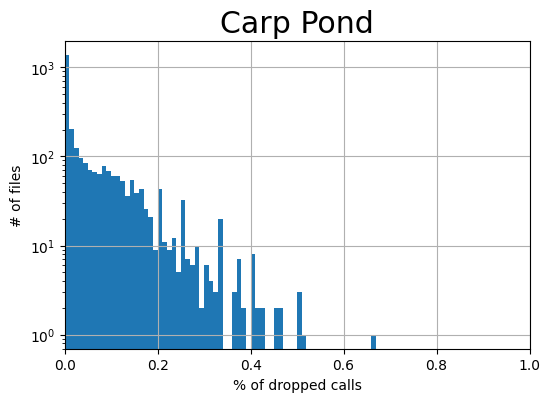

In [13]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
carp_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
ax.set_yscale('log')
plt.show()

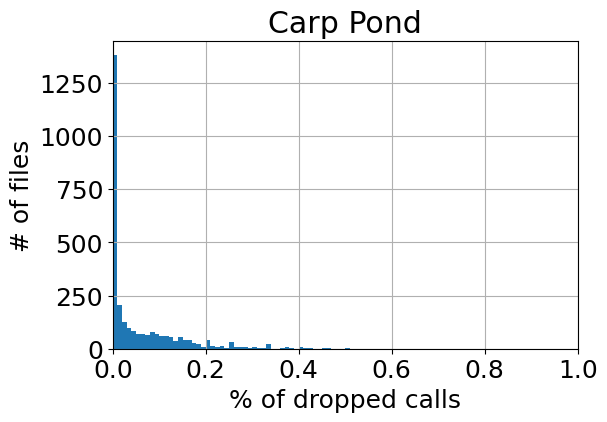

In [14]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
carp_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
plt.show()

In [15]:
carp_percentage_dropped_per_file_dt.median(), carp_percentage_dropped_per_file_dt.mean()

(0.011375947995666305, 0.05431909154848393)

In [16]:
data_params = dict()
data_params["site_tag"] = 'Telephone'
data_params["site_name"] = SITE_NAMES[data_params["site_tag"]]
data_params["type_tag"] = ''
data_params["detector_tag"] = 'bd2'
data_params["assembly_type"] = 'kmeans'
data_params['training_set'] = 'all_locations'

file_paths = get_file_paths(data_params)
file_paths['SITE_classes_file'] = f"{file_paths['SITE_classes_file'][:-4]}_raw.csv"
raw_location_df_filepath = Path(f'{file_paths["SITE_folder"]}/{data_params["detector_tag"]}__{data_params["site_tag"]}_2022_kmeans_raw.csv')
print(f'Reading from {raw_location_df_filepath}')
location_df_kmeans_raw = pd.read_csv(raw_location_df_filepath, low_memory=False, index_col=0)
location_df_kmeans_raw

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Telephone_classified_from_all_locations/bd2__Telephone_2022_kmeans_raw.csv


,index_in_file,SNR,peak_freq_time_infile,peak_frequency,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,call_end_time,...,class,class_prob,det_prob,individual,event,input_file,Site name,Recover Folder,SD Card,File Duration
0,14141,1.745165,145.592744,52800.0,0,2022-07-23 00:00:00,HF,2022-07-23 00:02:25.588500000,2022-07-23 00:02:25.588500000,2022-07-23 00:02:25.599600000,...,Pipistrellus pygmaeus,0.119,0.217,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
1,14726,2.113615,151.590052,58560.0,1,2022-07-23 00:00:00,HF,2022-07-23 00:02:31.582500000,2022-07-23 00:02:31.582500000,2022-07-23 00:02:31.594100000,...,Pipistrellus pygmaeus,0.196,0.204,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
2,15475,0.067695,159.319584,33600.0,2,2022-07-23 00:00:00,LF,2022-07-23 00:02:39.316500000,2022-07-23 00:02:39.316500000,2022-07-23 00:02:39.328200000,...,Eptesicus serotinus,0.087,0.269,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
3,22590,1.816045,232.423424,40320.0,3,2022-07-23 00:00:00,HF,2022-07-23 00:03:52.418500000,2022-07-23 00:03:52.418500000,2022-07-23 00:03:52.427800000,...,Pipistrellus nathusii,0.187,0.231,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
4,28985,0.060158,298.228604,26880.0,4,2022-07-23 00:00:00,LF,2022-07-23 00:04:58.215500000,2022-07-23 00:04:58.215500000,2022-07-23 00:04:58.229500000,...,Nyctalus leisleri,0.128,0.217,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2443272,25540,0.792924,548.984808,24960.0,2589228,2022-10-17 15:30:00,LF,2022-10-17 15:39:08.980500000,2022-10-17 15:39:08.980500000,2022-10-17 15:39:08.993900000,...,Nyctalus leisleri,0.116,0.331,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2443273,36620,1.068091,790.987117,23040.0,2589229,2022-10-17 15:30:00,LF,2022-10-17 15:43:10.976500000,2022-10-17 15:43:10.976500000,2022-10-17 15:43:10.993800000,...,Nyctalus leisleri,0.165,0.265,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2443274,39126,1.460107,845.762908,33600.0,2589230,2022-10-17 15:30:00,LF,2022-10-17 15:44:05.762500000,2022-10-17 15:44:05.762500000,2022-10-17 15:44:05.772800000,...,Eptesicus serotinus,0.151,0.213,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2443275,64058,0.260246,1399.392583,27840.0,2589232,2022-10-17 15:30:00,LF,2022-10-17 15:53:19.391500000,2022-10-17 15:53:19.391500000,2022-10-17 15:53:19.402000000,...,Eptesicus serotinus,0.138,0.232,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795


In [17]:
file_paths = get_file_paths(data_params)
location_df_kmeans = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
location_df_kmeans

,index_in_file,SNR,peak_freq_time_infile,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,...,class,class_prob,det_prob,individual,event,input_file,Site name,Recover Folder,SD Card,File Duration
0,14141,1.745165,145.592744,54687.5,52800.0,0,2022-07-23 00:00:00,HF,2022-07-23 00:02:25.588500000,2022-07-23 00:02:25.588500000,...,Pipistrellus pygmaeus,0.119,0.217,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
1,14726,2.113615,151.590052,62500.0,58560.0,1,2022-07-23 00:00:00,HF,2022-07-23 00:02:31.582500000,2022-07-23 00:02:31.582500000,...,Pipistrellus pygmaeus,0.196,0.204,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
2,22590,1.816045,232.423424,39062.5,40320.0,3,2022-07-23 00:00:00,HF,2022-07-23 00:03:52.418500000,2022-07-23 00:03:52.418500000,...,Pipistrellus nathusii,0.187,0.231,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
3,28985,0.060158,298.228604,31250.0,26880.0,4,2022-07-23 00:00:00,LF,2022-07-23 00:04:58.215500000,2022-07-23 00:04:58.215500000,...,Nyctalus leisleri,0.128,0.217,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
4,49544,0.884885,509.495604,31250.0,29760.0,6,2022-07-23 00:00:00,LF,2022-07-23 00:08:29.492500000,2022-07-23 00:08:29.492500000,...,Eptesicus serotinus,0.143,0.253,-1,Echolocation,/mnt/ubna_data_01_mir/recover-20220725/UBNA_01...,Telephone Field,recover-20220725,10,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399877,19557,4.068347,420.450233,24000.0,24000.0,2589227,2022-10-17 15:30:00,LF,2022-10-17 15:37:00.441500000,2022-10-17 15:37:00.441500000,...,Nyctalus leisleri,0.341,0.363,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2399878,25540,0.792924,548.984808,24000.0,24960.0,2589228,2022-10-17 15:30:00,LF,2022-10-17 15:39:08.980500000,2022-10-17 15:39:08.980500000,...,Nyctalus leisleri,0.116,0.331,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2399879,36620,1.068091,790.987117,24000.0,23040.0,2589229,2022-10-17 15:30:00,LF,2022-10-17 15:43:10.976500000,2022-10-17 15:43:10.976500000,...,Nyctalus leisleri,0.165,0.265,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795
2399880,64058,0.260246,1399.392583,30000.0,27840.0,2589232,2022-10-17 15:30:00,LF,2022-10-17 15:53:19.391500000,2022-10-17 15:53:19.391500000,...,Eptesicus serotinus,0.138,0.232,-1,Echolocation,/mnt/ubna_data_02_mir/recover-20221017/UBNA_00...,Telephone Field,recover-20221017,7,1795


In [18]:
all_dropped_calls = location_df_kmeans_raw.groupby(by='input_file', group_keys=False).apply(lambda x : get_dropped_by_kmeans(x, location_df_kmeans))

dropped_calls_df = all_dropped_calls.sort_values('call_start_time').reset_index().reset_index()
raw_calls_df = location_df_kmeans_raw.sort_values('call_start_time').reset_index().reset_index()

raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()
dropped_per_file_dt = dropped_calls_df.groupby('input_file_dt').count()

telephone_percentage_dropped_per_file_dt = dropped_per_file_dt['index'].reindex(raw_per_file_dt['index'].index, fill_value=0) / raw_per_file_dt['index']

In [19]:
telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt>0.2]

input_file_dt
2022-07-23 01:00:00    0.222222
2022-07-23 12:30:00    0.250000
2022-07-24 03:00:00    0.210526
2022-07-24 14:30:00    0.250000
2022-07-25 00:00:00    0.222222
                         ...   
2022-10-16 09:00:00    0.222222
2022-10-16 11:00:00    0.250000
2022-10-16 14:00:00    0.250000
2022-10-16 15:00:00    0.250000
2022-10-17 15:00:00    0.285714
Name: index, Length: 75, dtype: float64

In [20]:
raw_per_file_dt.loc[telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt>0.2].index]['index'].mean()

94.29333333333334

In [21]:
raw_per_file_dt.loc[telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt>0.2].index]['index'].median()

8.0

In [22]:
dropped_per_file_dt.loc[telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt>0.2].index]['index'].mean()

21.573333333333334

In [23]:
dropped_per_file_dt.loc[telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt>0.2].index]['index'].median()

2.0

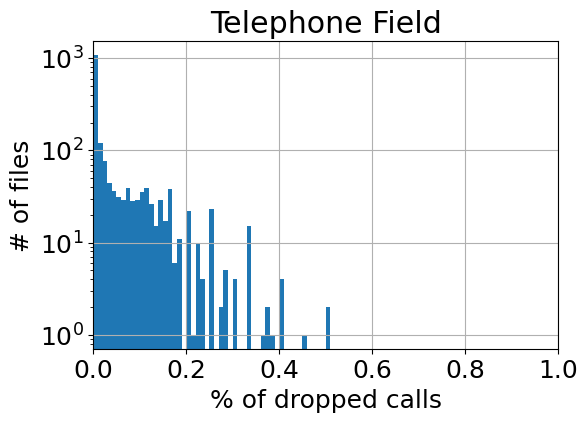

In [24]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
telephone_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
ax.set_yscale('log')
plt.show()

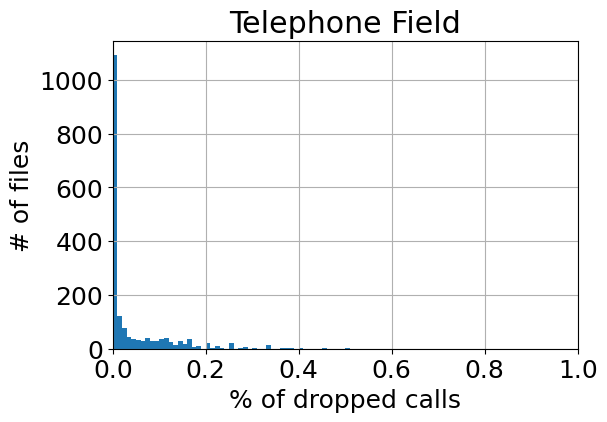

In [25]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
telephone_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
plt.show()

In [26]:
telephone_percentage_dropped_per_file_dt.median(), telephone_percentage_dropped_per_file_dt.mean()

(0.0023883181113564223, 0.040915133169235486)

In [27]:
telephone_percentage_dropped_per_file_dt.mean()

0.040915133169235486

In [28]:
(telephone_percentage_dropped_per_file_dt.mean() + carp_percentage_dropped_per_file_dt.mean())/2

0.04761711235885971

In [35]:
total_telephone = telephone_percentage_dropped_per_file_dt.count()
tel_num_files_with_less_than_p_dropped = telephone_percentage_dropped_per_file_dt[telephone_percentage_dropped_per_file_dt<0.01].count()

In [36]:
tel_num_files_with_less_than_p_dropped / total_telephone

0.5942265795206971

In [37]:
total_carp = carp_percentage_dropped_per_file_dt.count()
carp_num_files_with_less_than_p_dropped = carp_percentage_dropped_per_file_dt[carp_percentage_dropped_per_file_dt<0.01].count()

In [38]:
carp_num_files_with_less_than_p_dropped / total_carp

0.4854027435807246

In [39]:
(carp_num_files_with_less_than_p_dropped + tel_num_files_with_less_than_p_dropped) / (total_carp + total_telephone)

0.5281042957896986

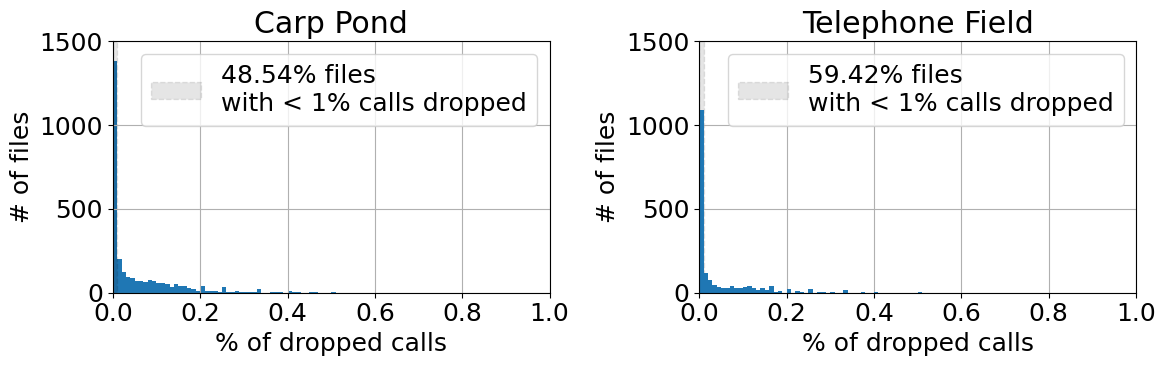

In [44]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
plt.rcParams.update({'font.size':18})

ax1.set_title(f'Carp Pond')
carp_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax1)
ax1.axvspan(xmin=0, xmax=0.01, linestyle='dashed', color='k', alpha=0.1, zorder=1, label=f'{round(100*(carp_num_files_with_less_than_p_dropped / total_carp), 2)}% files\nwith < 1% calls dropped')
ax1.set_xlim(0,1)
ax1.set_ylim(0,1500)
ax1.set_xlabel('% of dropped calls')
ax1.set_ylabel('# of files')
ax1.legend()

ax2.set_title(f'Telephone Field')
telephone_percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax2, zorder=2)
ax2.axvspan(xmin=0, xmax=0.01, linestyle='dashed', color='k', alpha=0.1, zorder=1, label=f'{round(100*(tel_num_files_with_less_than_p_dropped / total_telephone), 2)}% files\nwith < 1% calls dropped')
ax2.set_xlim(0,1)
ax2.set_ylim(0,1500)
ax2.set_xlabel('% of dropped calls')
ax2.set_ylabel('# of files')
ax2.legend()

fig.tight_layout()
plt.show()